# Processing of CSF and plasma SILK data

This notebook outlines the data used for parameter estimation in the mathematical model without antibody.

In [1]:
# import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## CSF SILK Data

CSF SILK data was obtained from Elbert et al. 2022. We use the data to obtain: i) CSF profiles of leucine-labelled Ab42; ii) CSF and plasma fraction leucine labelled profiles; and iii) mean CSF Ab42 concentrations.
We obtain these datasets for older, amyloid-positive individuals, which we use to fit our disease base model, as well as younger, amyloid-negative individuals, which we use to fit our healthy base model.

In [19]:
# Read in the data from Elbert et al. Commun Biol. 2022
data_and_parameters = pd.read_csv('patient_metadata.csv')

patient_numbers = pd.read_csv('patient_processing_order.csv', header=None).values
Ab42_concentrations = pd.read_csv('total_Ab42_concentrations.csv', header=None).values

MFL_Ab42 = pd.read_csv('Ab42_mol_fraction_labeled.csv', header=None).values
MFL_leucine = pd.read_csv('leucine_mol_fraction_labeled.csv', header=None).values

MFL_Ab42_times = pd.read_csv('Ab42_MFL_timepoints.csv', header=None).values

We begin by processing the data and extracting mean concentrations of CSF Ab42.

In [20]:
# subest individuals

amyloid_positive = data_and_parameters[data_and_parameters['Group_2']=='amyloid positive']['Subjects']
amyloid_negative = data_and_parameters[data_and_parameters['Group_2']=='amyloid negative']['Subjects']
young_and_negative = data_and_parameters[(data_and_parameters['Group_2']=='amyloid negative') & (data_and_parameters['Age']<60)]['Subjects']

In [23]:
# process normalised MFL to concentration of labeled Ab42
normalised_MFL_Ab42_positive = list()
unnormalised_MFL_positive = list()
normalised_MFL_Ab42_negative = list()
total_Ab42_positive = list()
total_Ab42_negative = list()
baselines_positive = list()

for i, patient in enumerate(patient_numbers):
    Ab42_pre = np.trim_zeros(MFL_Ab42[i, :], trim='b') # trim to account for variable number of datapoints
    times = np.trim_zeros(MFL_Ab42_times[i, :], trim='b') # times within 48h period to position above datapoints
    
    Ab42_post = [0]*49 # pre-allocate array to store relevant time points for each individual
    for n, val in enumerate(Ab42_pre):
        Ab42_post[times[n]] = val
    
    leucine = np.mean(MFL_leucine[i, :10]) # labeled leucine plateau during labelling

    norm = np.divide(Ab42_post, leucine) # normalise labeled Ab42 by leucine plateau as per Patterson 2015
    # norm_csf = np.divide(Ab42_post, leucine*(2/3)) # approximate CSF labeled leucine at 2/3 plasma labeled leucine according to Bateman et al. 2006
    
    total = np.multiply(Ab42_post, Ab42_concentrations[i][0]) # convert fraction to concentration value
    
    # separate data for amyloid positive and amyloid negative individuals
    if patient[0] in amyloid_positive.values:
        normalised_MFL_Ab42_positive.append(norm)
        unnormalised_MFL_positive.append(Ab42_post)
        total_Ab42_positive.append(total)
        baselines_positive.append(Ab42_concentrations[i][0])
    elif patient[0] in amyloid_negative.values:
        normalised_MFL_Ab42_negative.append(norm)
        total_Ab42_negative.append(total)
    else:
        continue # there are 4 patients categorised as neither amyloid positive or amyloid negative


In [24]:
print('Positive Mean Ab42 concentration: ', ((((np.mean(baselines_positive)*1000)*1e-9)/4514)/1e-9), ' nM')

Positive Mean Ab42 concentration:  0.15040225730475945  nM


In [25]:
# process normalised MFL to concentration of labeled Ab42
normalised_MFL_Ab42_young = list()
unnormalised_MFL_young = list()
normalised_MFL_Ab42_young = list()
total_Ab42_young = list()

baselines=list()

for i, patient in enumerate(patient_numbers):
    Ab42_pre = np.trim_zeros(MFL_Ab42[i, :], trim='b') # trim to account for variable number of datapoints
    times = np.trim_zeros(MFL_Ab42_times[i, :], trim='b') # times within 48h period to position above datapoints
    
    Ab42_post = [0]*49 # pre-allocate array to store relevant time points for each individual
    for n, val in enumerate(Ab42_pre):
        Ab42_post[times[n]] = val
    
    leucine = np.mean(MFL_leucine[i, :10]) # labeled leucine plateau during labelling

    norm = np.divide(Ab42_post, leucine) # normalise labeled Ab42 by leucine plateau as per Patterson 2015
    # norm_csf = np.divide(Ab42_post, leucine*(2/3)) # approximate CSF labeled leucine at 2/3 plasma labeled leucine according to Bateman et al. 2006
    
    total = np.multiply(Ab42_post, Ab42_concentrations[i][0]) # convert fraction to concentration value
    
    # separate data for amyloid positive and amyloid negative individuals
    if patient[0] in young_and_negative.values:
        normalised_MFL_Ab42_young.append(norm)
        unnormalised_MFL_young.append(Ab42_post)
        total_Ab42_young.append(total)
        baselines.append(Ab42_concentrations[i][0])

In [26]:
print('Young mean Ab42 concentration: ', ((((np.mean(baselines)*1000)*1e-9)/4514)/1e-9), ' nM')

Young mean Ab42 concentration:  0.2481911829862649  nM


We next calculate the mean CSF labelled Ab42 profiles.

In [27]:
# replace the concentrations for unknown time points with 'nan'
total_Ab42_positive = np.reshape(total_Ab42_positive,(-1,49))
total_Ab42_positive[total_Ab42_positive==0]=['nan']

total_Ab42_negative = np.reshape(total_Ab42_negative,(-1,49))
total_Ab42_negative[total_Ab42_negative==0]=['nan']

total_Ab42_young = np.reshape(total_Ab42_young,(-1,49))
total_Ab42_young[total_Ab42_young==0]=['nan']

In [33]:
# calculate the mean Ab42 concentration across all available datapoints for each time
mean_amount_Ab42_positive = np.nanmean(total_Ab42_positive, axis=0)[:37]
mean_amount_Ab42_negative = np.nanmean(total_Ab42_negative, axis=0)[:37]
mean_amount_Ab42_young = np.nanmean(total_Ab42_young, axis=0)[:37]
amount_times = range(0, 37)

/var/folders/l5/vvvd6vv53p5c2fcx_mh240dw0000gn/T/ipykernel_41088/1299662838.py:2: RuntimeWarning: Mean of empty slice
  mean_amount_Ab42_positive = np.nanmean(total_Ab42_positive, axis=0)[:37]
/var/folders/l5/vvvd6vv53p5c2fcx_mh240dw0000gn/T/ipykernel_41088/1299662838.py:3: RuntimeWarning: Mean of empty slice
  mean_amount_Ab42_negative = np.nanmean(total_Ab42_negative, axis=0)[:37]
/var/folders/l5/vvvd6vv53p5c2fcx_mh240dw0000gn/T/ipykernel_41088/1299662838.py:4: RuntimeWarning: Mean of empty slice
  mean_amount_Ab42_young = np.nanmean(total_Ab42_young, axis=0)[:37]


In [29]:
# save standard deviations
sd_Ab42_positive = np.nanstd(total_Ab42_positive, axis=0)[:37]
np.savetxt('csf_SILK_std.csv', sd_Ab42_positive, delimiter=',', fmt='%s')

/Users/laraherriott/Documents/DPhil/brainshuttle_QSP/QSP_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [30]:
# save standard deviations
sd_Ab42_young = np.nanstd(total_Ab42_young, axis=0)[:37]
np.savetxt('SILK_sd_young.csv', sd_Ab42_young, delimiter=',', fmt='%s')

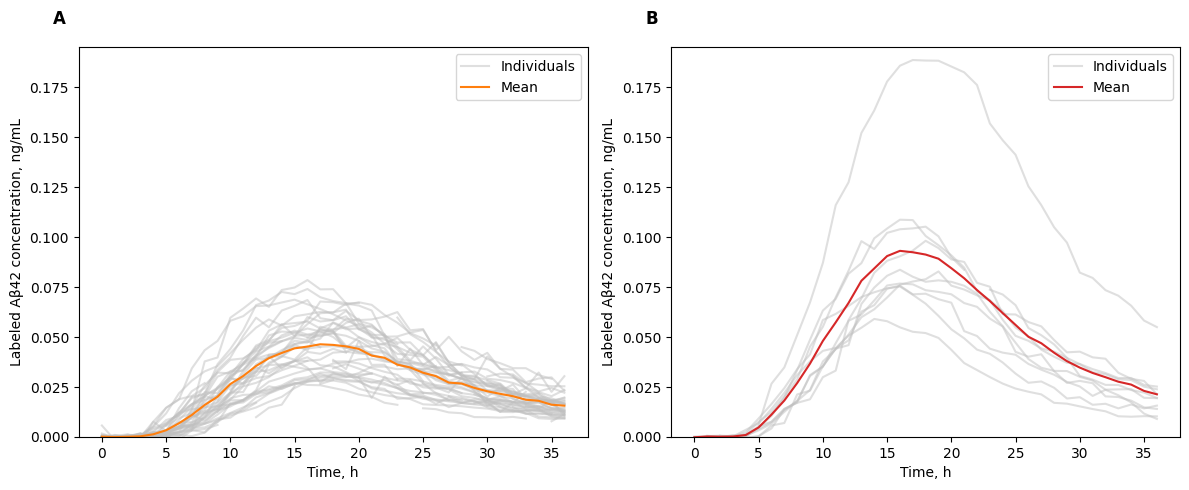

In [31]:
# Create a figure with two subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Subplot A: Amyloid positive
axs[0].plot(amount_times, total_Ab42_positive[-1][:37], color='silver', alpha=0.5, label='Individuals')
for person in total_Ab42_positive[:-1]:
    axs[0].plot(amount_times, person[:37], color='silver', alpha=0.5)
axs[0].plot(amount_times, mean_amount_Ab42_positive, color='tab:orange', label='Mean')
axs[0].set_xlabel('Time, h')
axs[0].set_ylabel('Labeled Aβ42 concentration, ng/mL')
axs[0].text(-0.05, 1.05, 'A', transform=axs[0].transAxes, fontsize=12, fontweight='bold', va='bottom', ha='left')
axs[0].set_ylim(0, 0.195)

axs[0].legend()

# Subplot B: Amyloid negative - Young
axs[1].plot(amount_times, total_Ab42_young[-1][:37], color='silver', alpha=0.5, label='Individuals')
for person in total_Ab42_young[:-1]:
    axs[1].plot(amount_times, person[:37], color='silver', alpha=0.5)
axs[1].plot(amount_times, mean_amount_Ab42_young, color='tab:red', label='Mean')
axs[1].set_xlabel('Time, h')
axs[1].set_ylabel('Labeled Aβ42 concentration, ng/mL')
axs[1].text(-0.05, 1.05, 'B', transform=axs[1].transAxes, fontsize=12, fontweight='bold', va='bottom', ha='left')
axs[1].set_ylim(0, 0.195)
axs[1].legend()

plt.tight_layout()
#plt.show()
plt.savefig('../Plots/CSF_SILK_data_QSP_paper.png', dpi=300)

In [16]:
# convert ng/mL to nM
mean_nM_Ab42_positive = [((((x*1000)*1e-9)/4514)/1e-9) for x in mean_amount_Ab42_positive]
mean_nM_Ab42_negative = [((((x*1000)*1e-9)/4514)/1e-9) for x in mean_amount_Ab42_negative]
mean_nM_Ab42_young = [((((x*1000)*1e-9)/4514)/1e-9) for x in mean_amount_Ab42_young]

mean_nM_Ab42_positive = np.insert(mean_nM_Ab42_positive, 0, 1)
mean_nM_Ab42_negative = np.insert(mean_nM_Ab42_negative, 0, 0)
mean_nM_Ab42_young = np.insert(mean_nM_Ab42_young, 0, 0)

In [17]:
# save mean concentrations for all amyloid positive and negative individuals
np.savetxt('mean_Ab42_CSF_SILK.csv', [p for p in zip(mean_nM_Ab42_positive, mean_nM_Ab42_negative)], delimiter=',', fmt='%s')

In [18]:
# save mean concentrations for all amyloid negative and young individuals
np.savetxt('mean_nM_Ab42_young_CSF_SILK.csv', mean_nM_Ab42_young, delimiter=',', fmt='%s')

We next determine the mean fraction leucine labeled for use in model.

In the model, production of labeled leucine will be simulated by scaling the Ab42 production rate by the fraction leucine labeled. In Elbert et al. 2022, plasma leucine MFL data is provided for each individual. We take the mean plasma profile to scale plasma Ab42 production, and also derive a mean CSF profile to scale brain Ab42 production.

In [35]:
# data from Elbert et al. 2022 provides plasma leucine MFL data for each individual
mean_f_leu = np.mean(MFL_leucine, axis=0)
np.savetxt('mean_f_leu.csv', mean_f_leu, delimiter=',', fmt='%s')

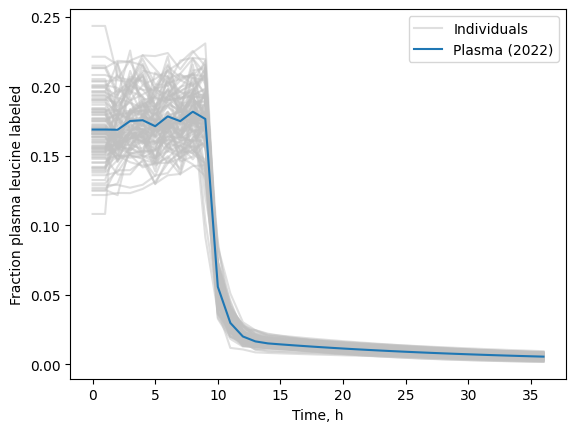

In [ ]:
# plotting individual plasma leucine profiles alongside the mean profile
plt.plot(range(37), MFL_leucine[-1][:37], color='silver', alpha=0.5, label = 'Individuals')
for person in MFL_leucine[:-1]:
    plt.plot(range(37), person[:37], color='silver', alpha=0.5)
plt.plot(range(37), mean_f_leu[:37], label='Plasma (2022)')
plt.xlabel('Time, h')
plt.ylabel('Leucine MFL')
plt.legend()
plt.show()

In the Bateman et al. 2006 study '', both plasma and CSF fraction leucine labelled profiles were presented. The CSF plateau was 0.6807134457742796 the plasma plateau. Clearance of labelled leucine from the CSF was also slower than that from the plasma. We use this data to estimate a CSF leucine profile corresponding to the plasma leucine profile provided.

In [37]:
# read in digitized data from Bateman et al. 2006
df_2006 = pd.read_csv('plasma_vs_csf_leucineTTR.csv')

We first apply the scale factor of 0.6807134457742796 to the mean plasma profile from the 2022 cohort to obtain an initial approximation for the mean CSF profile:

In [38]:
mean_f_leu_csf = [x*(0.6807134457742796) for x in mean_f_leu[:37]]

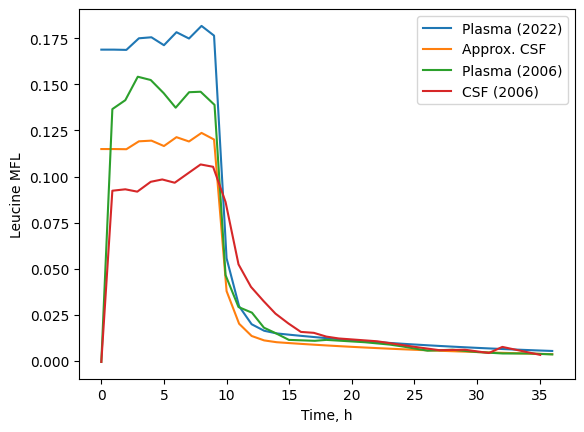

In [40]:
# plot this initial approximation alongside the digitized data from Bateman et al. 2006
plt.plot(range(37), mean_f_leu[:37], label='Plasma (2022)')
plt.plot(range(37), mean_f_leu_csf, label='Approx. CSF')

plt.plot(df_2006['time1'], df_2006['plasma']/100, label='Plasma (2006)')
plt.plot(df_2006['time2'], df_2006['csf']/100, label='CSF (2006)')
plt.xlabel('Time, h')
plt.ylabel('Leucine MFL')
plt.legend()
plt.show()

To approximate the slower clearance from the CSF, we fit a curve to the exponential decay portion of the Bateman et al. 2006 CSF data.

In [42]:
# scale the Bateman et al. 2006 CSF data to match the 2022 approximated CSF plateau
exponential = 1.2102193625379605*(df_2006['csf']/100)[10:]

In [43]:
# fit a curve to the exponential decay portion of the Bateman et al. 2006 CSF data
import scipy
p_fitted = scipy.optimize.curve_fit(lambda t,a,b: a*np.exp(-t * b),  df_2006['time2'][10:],  exponential)
y = [(p_fitted[0][0]*np.exp(-x*p_fitted[0][1])) for x in [x+10 for x in range(len(df_2006['time2'][10:]))]]

/Users/laraherriott/Documents/DPhil/brainshuttle_QSP/QSP_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [44]:
# replace the clearance phase of the CSF approximation with the fit
add_first = np.append(mean_f_leu_csf[:10], y) # concatenate plateau to start of decay curve
final_value = [float(add_first[-1])]*(37-len(add_first)) # extend data up to 37 hours by copying final value
csf_approximation = np.append(add_first, final_value) # concatenate plateau and decay to extension


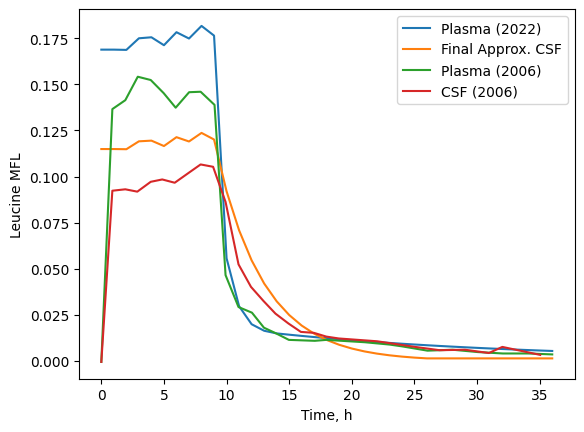

In [46]:
# plot the final CSF approximation alongside the digitized data from Bateman et al. 2006
plt.plot(range(37), mean_f_leu[:37], label='Plasma (2022)')
plt.plot(range(37), csf_approximation, label='Final Approx. CSF')

plt.plot(df_2006['time1'], df_2006['plasma']/100, label='Plasma (2006)')
plt.plot(df_2006['time2'], df_2006['csf']/100, label='CSF (2006)')

plt.xlabel('Time, h')
plt.ylabel('Leucine MFL')
plt.legend()
plt.show()

In [47]:
# save the final CSF approximation
np.savetxt('mean_f_leu_csf.csv', csf_approximation, delimiter=',', fmt='%s')

## Plasma SILK Data

Plasma SILK data was obtained from Ovod et al. 2017 and corresponding labelled leucine profiles were taken from Sato et al. 2018, which used the same SILK experimental protocol. We use the data to obtain: i) Plasma profiles of leucine-labelled Ab42; ii) CSF and plasma fraction leucine labelled profiles; and iii) mean plasma Ab42 concentrations.
The leucine-labelled Ab42 profiles are presented for amyloid-positive and -negative individuals together. However, mean plasma Ab42 concentrations were presented for amyloid-positive and -negative patients separately.

The concentration of Abeta42 in amyloid-positive individuals was reported as 37.13 pg/ml while that of amyloid-negative individuals was reported as 30.13 pg/ml.

In [57]:
plasma_Ab42_positive = 37.13/(4514)
plasma_Ab42_negative = 30.13/(4514)
print('Plasma Ab42 concentration in amyloid-positive individuals: ', plasma_Ab42_positive, 'nM')
print('Plasma Ab42 concentration in amyloid-negative individuals: ', plasma_Ab42_negative, 'nM')

Plasma Ab42 concentration in amyloid-positive individuals:  0.008225520602569784 nM
Plasma Ab42 concentration in amyloid-negative individuals:  0.0066747895436420025 nM


We next extract the mean plasma labelled Ab42 profiles.

In [48]:
# read in the plasma SILK data digitized from Ovod et al. 2017, Figure 1A (left)
plasma_df = pd.read_csv('plasma_silk_digitized.csv')
plasma_times = plasma_df.iloc[:, 0]

In [50]:
# read in the leucine MFL data digitized from Sato et al. 2018, Figure S6
leucine_mfl = pd.read_csv('bolus_800_plasma_leucine_MFL.csv')
time = leucine_mfl['Time, h'].values

From Ovod et al. 2017, it is unclear how the Abeta42 MFL was normalized according to leucine labelling. However, in Sato et al. 2018 the Abeta42 MFL was normalized to the area under the plasma labeled leucine curve. We therefore assume the same process was used in Ovod et al. 2017.

In [ ]:
# calculate the area under the plasma labeled leucine curve
AUC = np.trapezoid(leucine_mfl['MFL'], time)
print('Area under the curve: ', AUC)

Area under the curve:  0.8799657293261557


To obtain concentrations of labelled Ab42, we therefore divide the multiple MFL profile by the AUC, and then by the total concentration of Ab42.

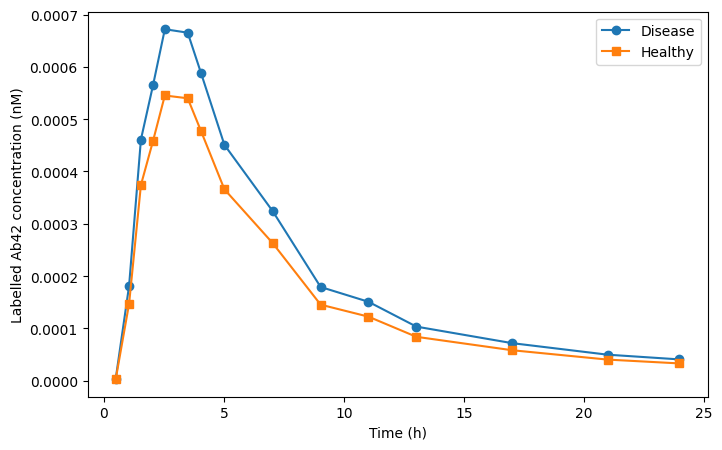

In [60]:
# process the plasma Ab42 MFL data by both methods, converting the MFLs to concentrations in nM
plasma_vals_auc_disease = [(x*AUC)*(0.008225520602569784) for x in plasma_df.iloc[:, 1]]
plasma_vals_auc_healthy = [(x*AUC)*(0.0066747895436420025) for x in plasma_df.iloc[:, 1]]

plt.figure(figsize=(8, 5))
plt.plot(plasma_times, plasma_vals_auc_disease, label="Disease", marker='o')
plt.plot(plasma_times, plasma_vals_auc_healthy, label="Healthy", marker='s')
plt.xlabel("Time (h)")
plt.ylabel("Labelled Ab42 concentration (nM)")
plt.legend()
plt.show()

We next determine the mean fraction leucine labeled for use in model.

Sato et al. 2018 presented the plasma concentration of labelled leucine. We apply the same scale factor of 0.6807134457742796 that was used to obtain a CSF leucine profile for the CSF SILK experiments above.

In [62]:
# process the plasma profile from Sato et al. 2018
mfl_leu = leucine_mfl['MFL'].values
final_value = [float(mfl_leu[-1])]*15 # extend the profile from Sato 2018 up to the duration of Ocod 2017
f_leu_plasma = np.append(mfl_leu, final_value) # concatenate the data to the extension

In [70]:
# Fit a curve to the plasma leucine MFL profile and scale it to estimate the CSF leucine profile
p_fitted_plasma = scipy.optimize.curve_fit(lambda t,a,b: a*np.exp(-t * b),  leucine_mfl['Time, h'].values,  mfl_leu)
y_plasma = [(p_fitted_plasma[0][0]*np.exp(-x*p_fitted_plasma[0][1])) for x in range(10)]
# similarly extend the fit
fit_leu_plasma = np.append(y_plasma, [float(y_plasma[-1])]*15)
fit_leu_CSF = 0.6807134457742796*fit_leu_plasma
time_fit = list(range(25))

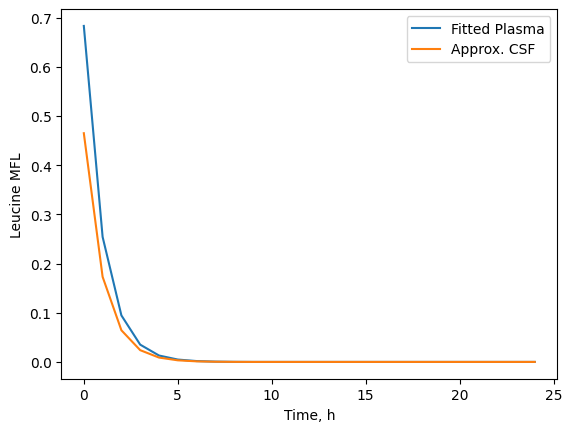

In [73]:
# compare the plasma leucine MFL profiles above to a scaled approximation of the CSF leucine MFL profile
plt.plot(time_fit, fit_leu_plasma, label='Fitted Plasma')
plt.plot(time_fit, fit_leu_CSF, label='Approx. CSF')
plt.xlabel('Time, h')
plt.ylabel('Leucine MFL')
plt.legend()
plt.show()

In [74]:
np.savetxt('bolus_800_csf_new.csv', fit_leu_plasma, delimiter=',', fmt='%s')
np.savetxt('bolus_800_plasma_new.csv', fit_leu_plasma, delimiter=',', fmt='%s')

### Plot final leucine profiles used for SILK simulations

The overall differences in the profile result from different methods of administering the labelled leucine. In the CSF SILK experiments, and initial bolus injection was given followed by continuous infusion over the remainder of the ten hours. In the plasma SILK experiments, a single bolus injecton only was given.

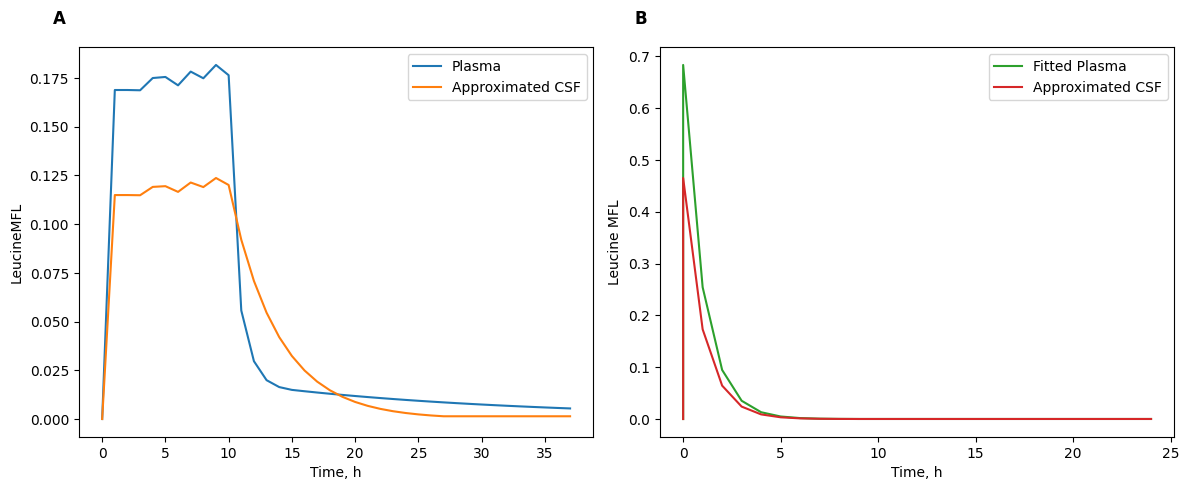

In [79]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# First subplot - CSF leucine profile
axs[0].plot(range(38), np.append([0],mean_f_leu[:37]), label='Plasma', color='tab:blue')
axs[0].plot(range(38), np.append([0],csf_approximation), label='Approximated CSF', color='tab:orange')
axs[0].set_xlabel('Time, h')
axs[0].set_ylabel('LeucineMFL')
axs[0].text(-0.05, 1.05, 'A', transform=axs[0].transAxes, fontsize=12, fontweight='bold', va='bottom', ha='left')
axs[0].legend()

# Second subplot - Plasma leucine profile
axs[1].plot(np.append([0], time_fit), np.append([0], fit_leu_plasma), label='Fitted Plasma', color='tab:green')
axs[1].plot(np.append([0],time_fit), np.append([0], fit_leu_CSF), label='Approximated CSF', color='tab:red')
axs[1].set_xlabel('Time, h')
axs[1].set_ylabel('Leucine MFL')
axs[1].text(-0.05, 1.05, 'B', transform=axs[1].transAxes, fontsize=12, fontweight='bold', va='bottom', ha='left')
axs[1].legend()

plt.tight_layout()
# plt.show()
plt.savefig('../Plots/SILK_leucine_profiles_QSP_paper.png', dpi=300)